<a href="https://colab.research.google.com/github/naitik-singh24/SCT_DS_4/blob/main/Task_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

%matplotlib inline

In [5]:
from google.colab import files
import zipfile
import pandas as pd
import os

# Upload ZIP
uploaded = files.upload()

# Get uploaded filename
zip_file = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("extracted_data")

print("Extracted Files:")
print(os.listdir("extracted_data"))

# Load CSV
csv_file = [f for f in os.listdir("extracted_data") if f.endswith('.csv')][0]
df = pd.read_csv(f"extracted_data/{csv_file}")



Saving RTA Dataset.csv.zip to RTA Dataset.csv (1).zip
Extracted Files:
['RTA Dataset.csv']


In [6]:
# BASIC INFORMATION

print(df.shape)

print(df.info())

df.describe(include="all")

(12316, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment    

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,...,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,...,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# MISSING VALUES

missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

,0
Defect_of_vehicle,4427
Service_year_of_vehicle,3928
Work_of_casuality,3198
Fitness_of_casuality,2635
Type_of_vehicle,950
Types_of_Junction,887
Driving_experience,829
Educational_level,741
Vehicle_driver_relation,579
Owner_of_vehicle,482


In [8]:
# REMOVE THE DUPLICATE RECORDS

df.drop_duplicates(inplace=True)

print(df.shape)

(12316, 32)


In [10]:
# FILL THE MISSING VALUES

for col in df.columns:

    if df[col].dtype=="object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

In [11]:
# CHECK AGAIN
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


In [12]:
# DATA OVERVIEW

df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

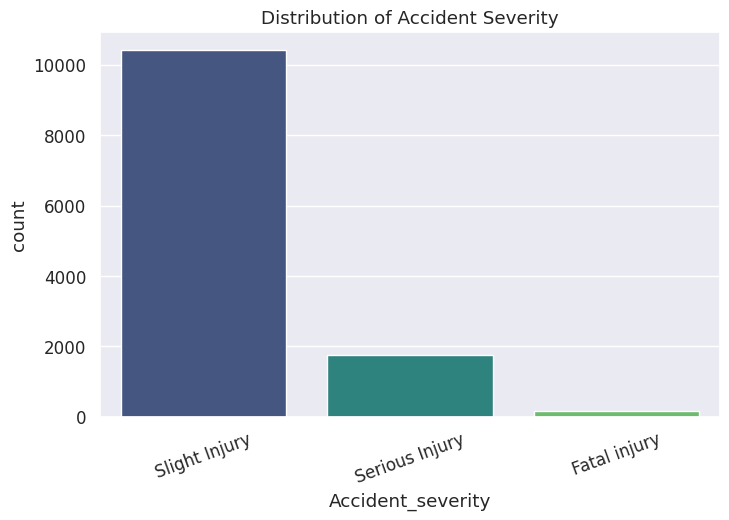

In [13]:
# ACCIDENT SEVERITY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='Accident_severity',
              palette='viridis')

plt.title("Distribution of Accident Severity")
plt.xticks(rotation=20)

plt.show()

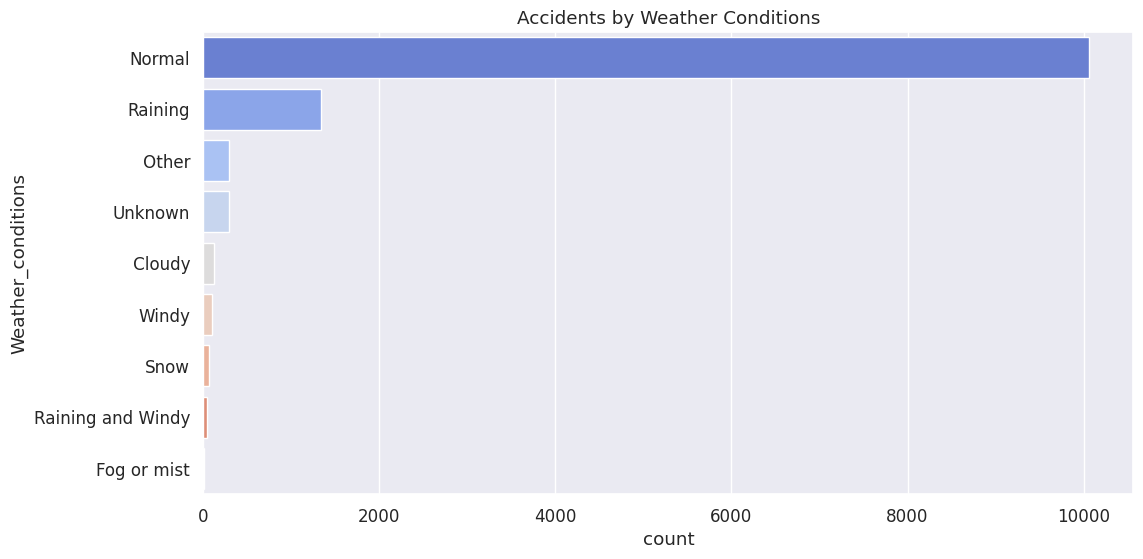

In [14]:
# WEATHER CONDITION ANALYSIS

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Weather_conditions",
    order=df["Weather_conditions"].value_counts().index,
    palette="coolwarm"
)

plt.title("Accidents by Weather Conditions")

plt.show()

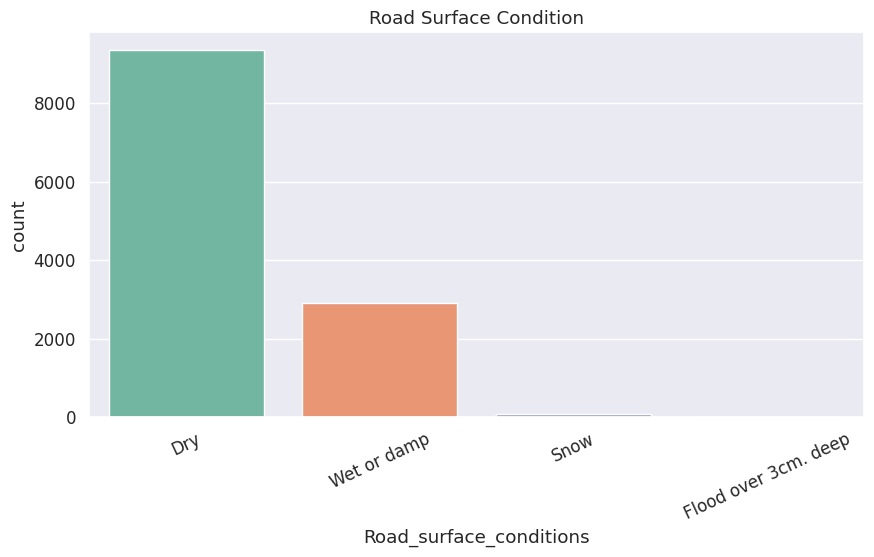

In [15]:
# ROAD SURFACE CONDITION

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Road_surface_conditions",
    palette="Set2"
)

plt.xticks(rotation=25)

plt.title("Road Surface Condition")

plt.show()

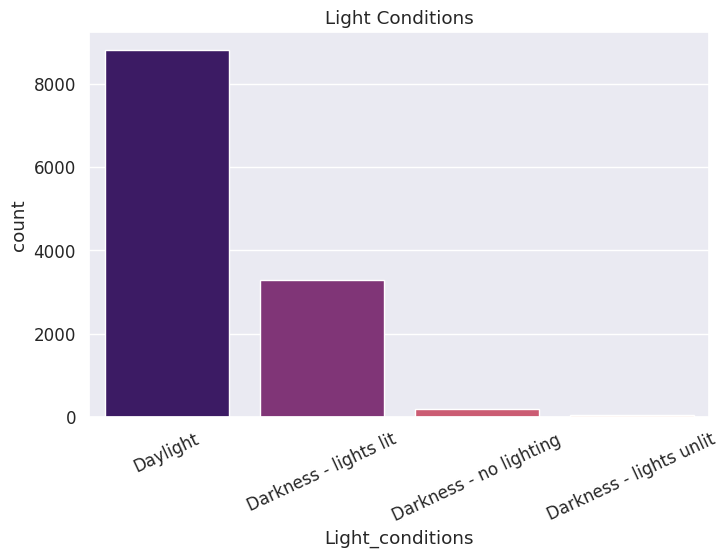

In [16]:
# LIGHT CONDITION

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Light_conditions",
    palette="magma"
)

plt.xticks(rotation=25)

plt.title("Light Conditions")

plt.show()

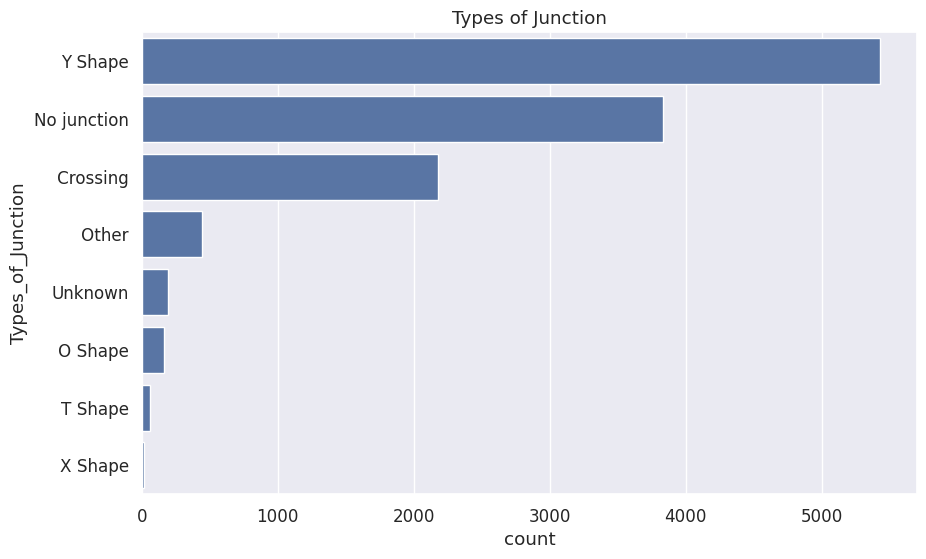

In [18]:
# JUNCTION TYPE

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Types_of_Junction",
    order=df["Types_of_Junction"].value_counts().index
)

plt.title("Types of Junction")

plt.show()

In [19]:
# TIME ANALYSIS

df["Time"] = pd.to_datetime(df["Time"])

df["Hour"] = df["Time"].dt.hour

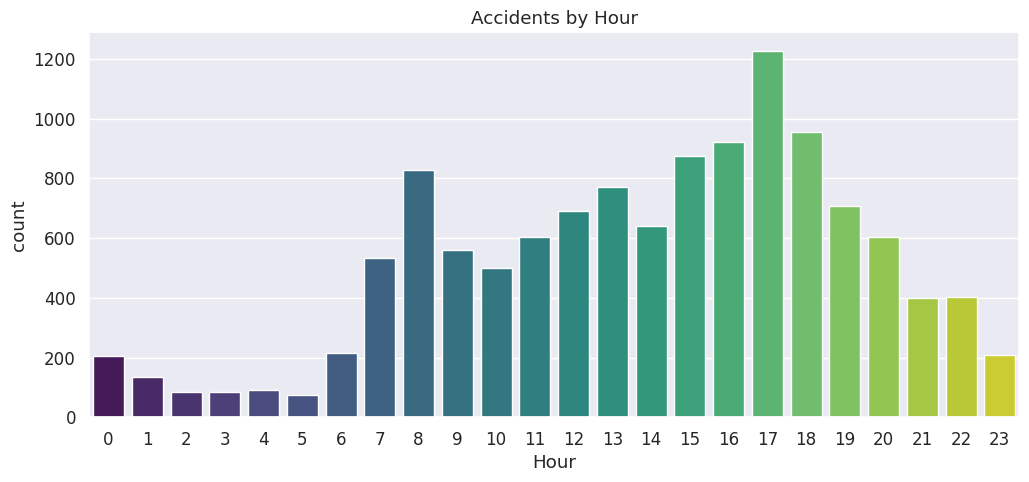

In [20]:
# ACCIDENTS BY HOURS

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Hour",
    palette="viridis"
)

plt.title("Accidents by Hour")

plt.show()

In [22]:
# CREATE TIME OF DAYS

def period(hour):

    if hour<6:
        return "Night"

    elif hour<12:
        return "Morning"

    elif hour<18:
        return "Afternoon"

    else:
        return "Evening"

df["Time_of_Day"] = df["Hour"].apply(period)

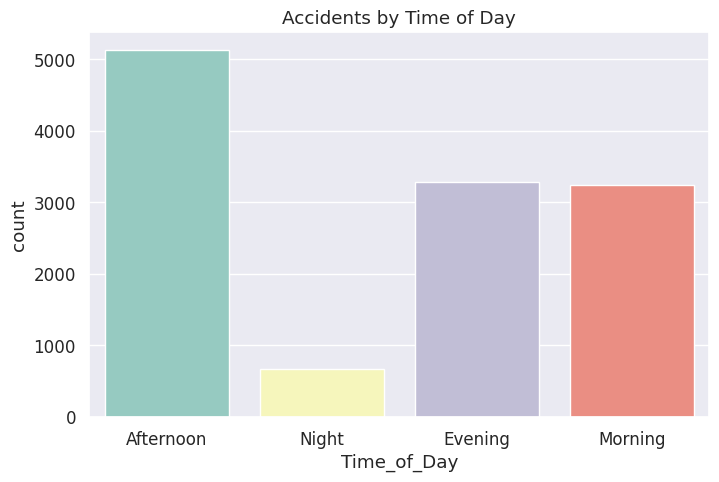

In [23]:
# PLOT TIME OF DAYS

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Time_of_Day",
    palette="Set3"
)

plt.title("Accidents by Time of Day")

plt.show()

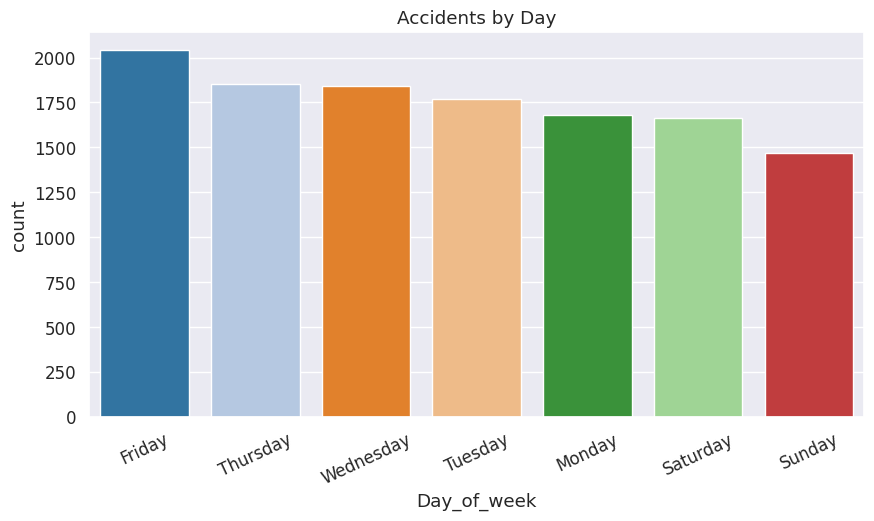

In [24]:
# DAYS OF WEEKS

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Day_of_week",
    order=df["Day_of_week"].value_counts().index,
    palette="tab20"
)

plt.xticks(rotation=25)

plt.title("Accidents by Day")

plt.show()

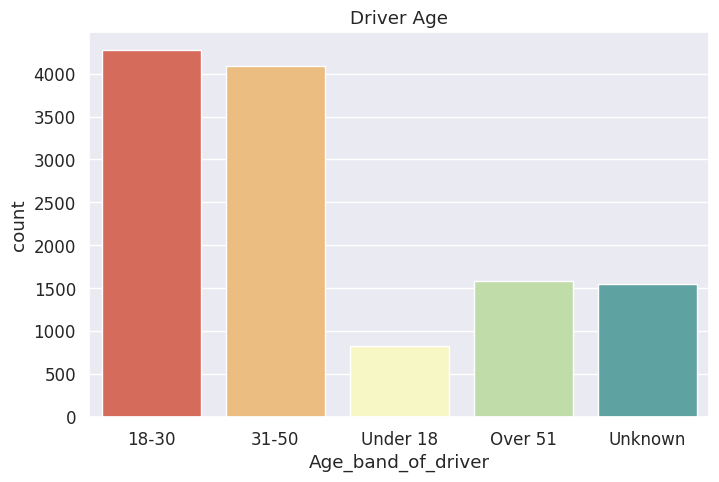

In [25]:
# DRIVER AGE

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age_band_of_driver",
    palette="Spectral"
)

plt.title("Driver Age")

plt.show()

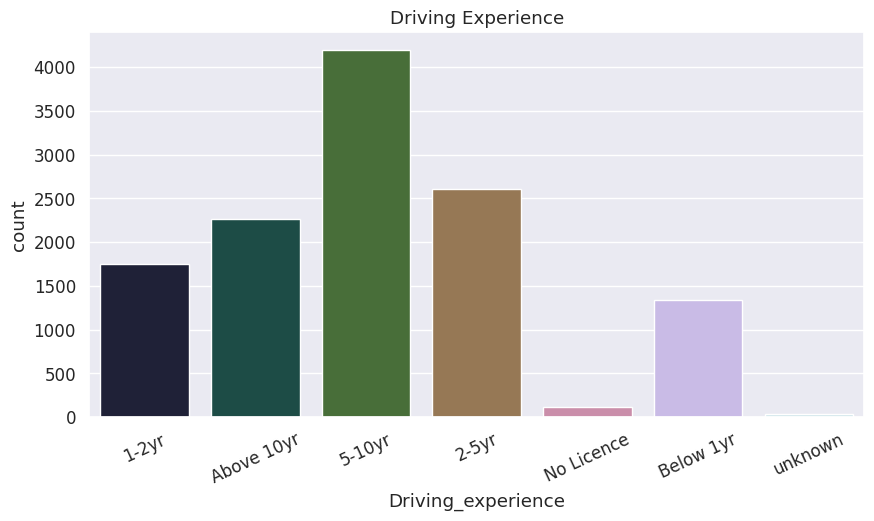

In [26]:
# DRIVER EXPERIENCES

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Driving_experience",
    palette="cubehelix"
)

plt.xticks(rotation=25)

plt.title("Driving Experience")

plt.show()

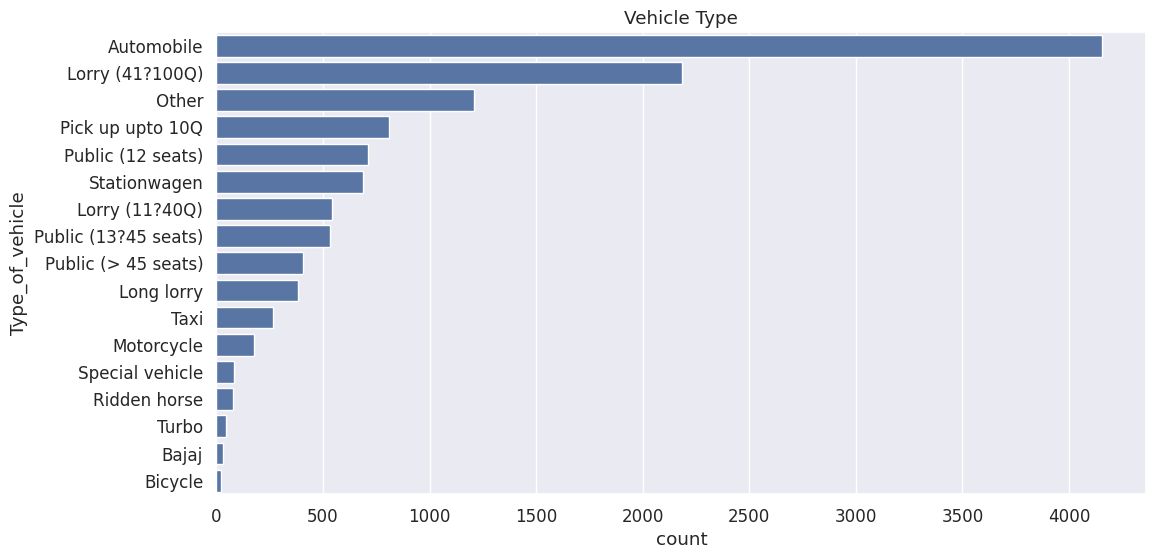

In [27]:
# VEHICLE TYPE

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Type_of_vehicle",
    order=df["Type_of_vehicle"].value_counts().index
)

plt.title("Vehicle Type")

plt.show()

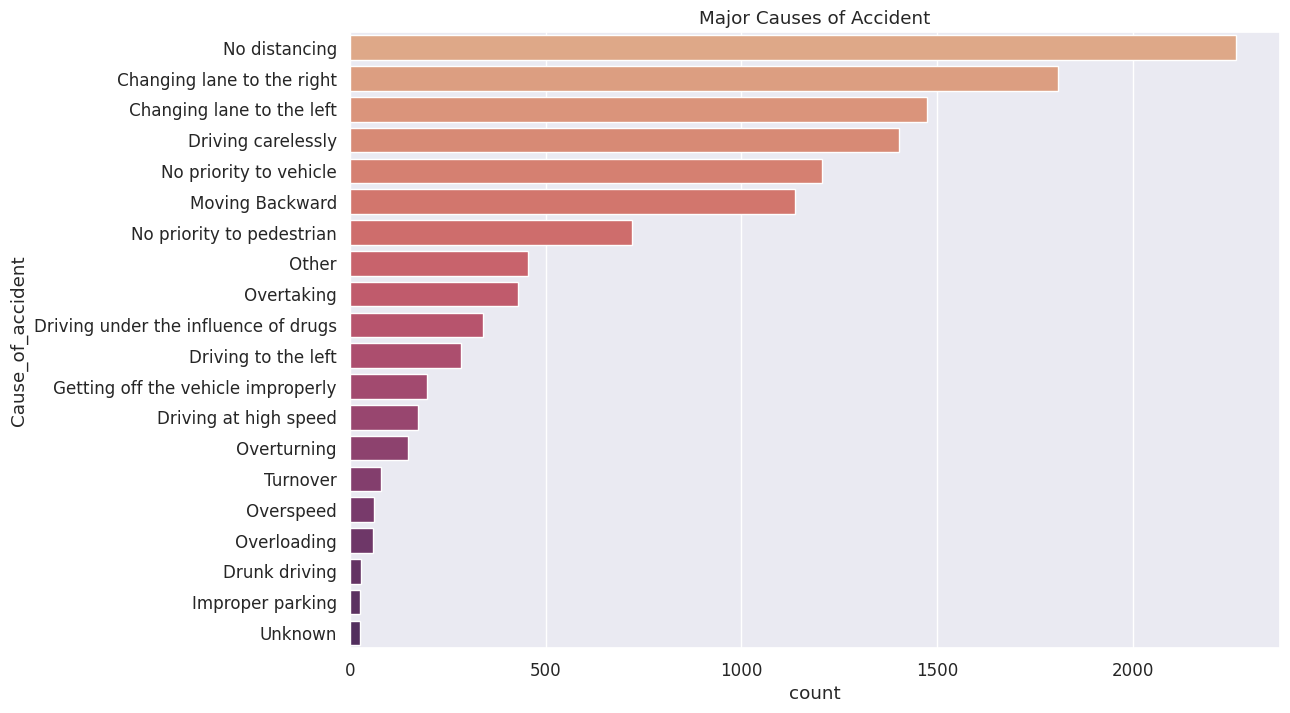

In [28]:
# CAUSE OF ACCIDENTS

plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="Cause_of_accident",
    order=df["Cause_of_accident"].value_counts().index,
    palette="flare"
)

plt.title("Major Causes of Accident")

plt.show()

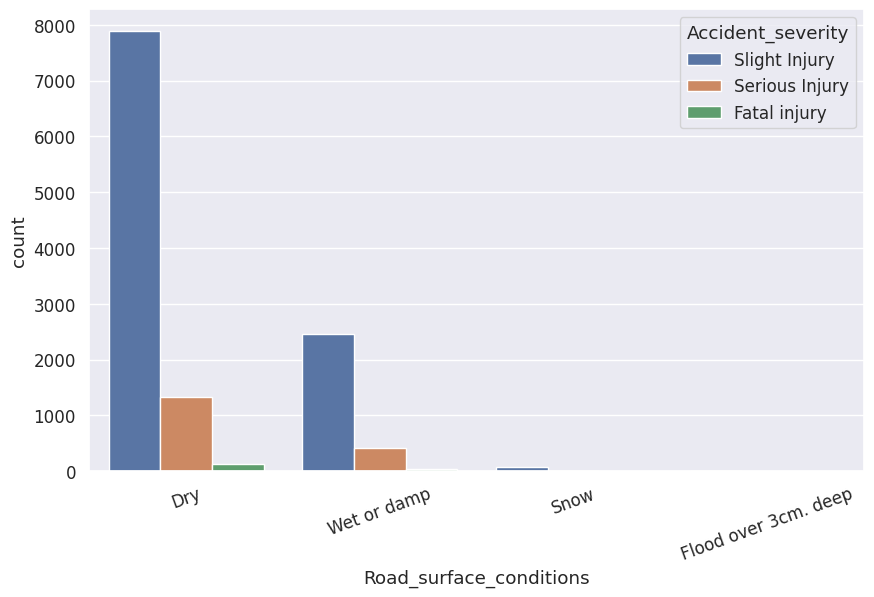

In [29]:
# ROAD SURFACE AND SEVERITY

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Road_surface_conditions",
    hue="Accident_severity"
)

plt.xticks(rotation=20)

plt.show()

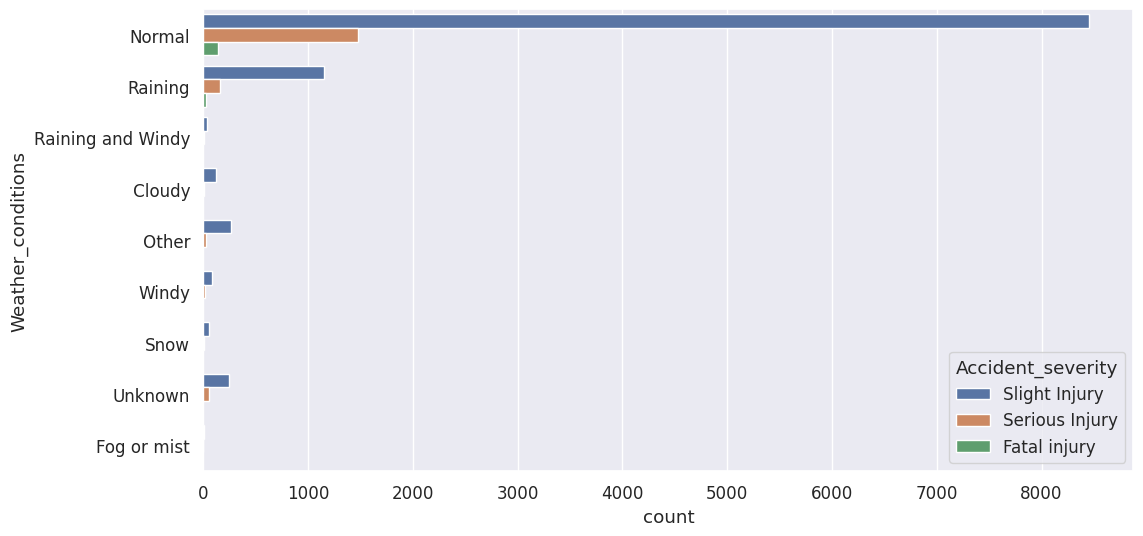

In [30]:
# WEATHER VS SEVERITY

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Weather_conditions",
    hue="Accident_severity"
)

plt.show()

In [32]:
# CORRELATION MATRIX

encoder = LabelEncoder()

encoded = df.copy()

for col in encoded.columns:

    if encoded[col].dtype=="object":

        encoded[col] = encoder.fit_transform(encoded[col])




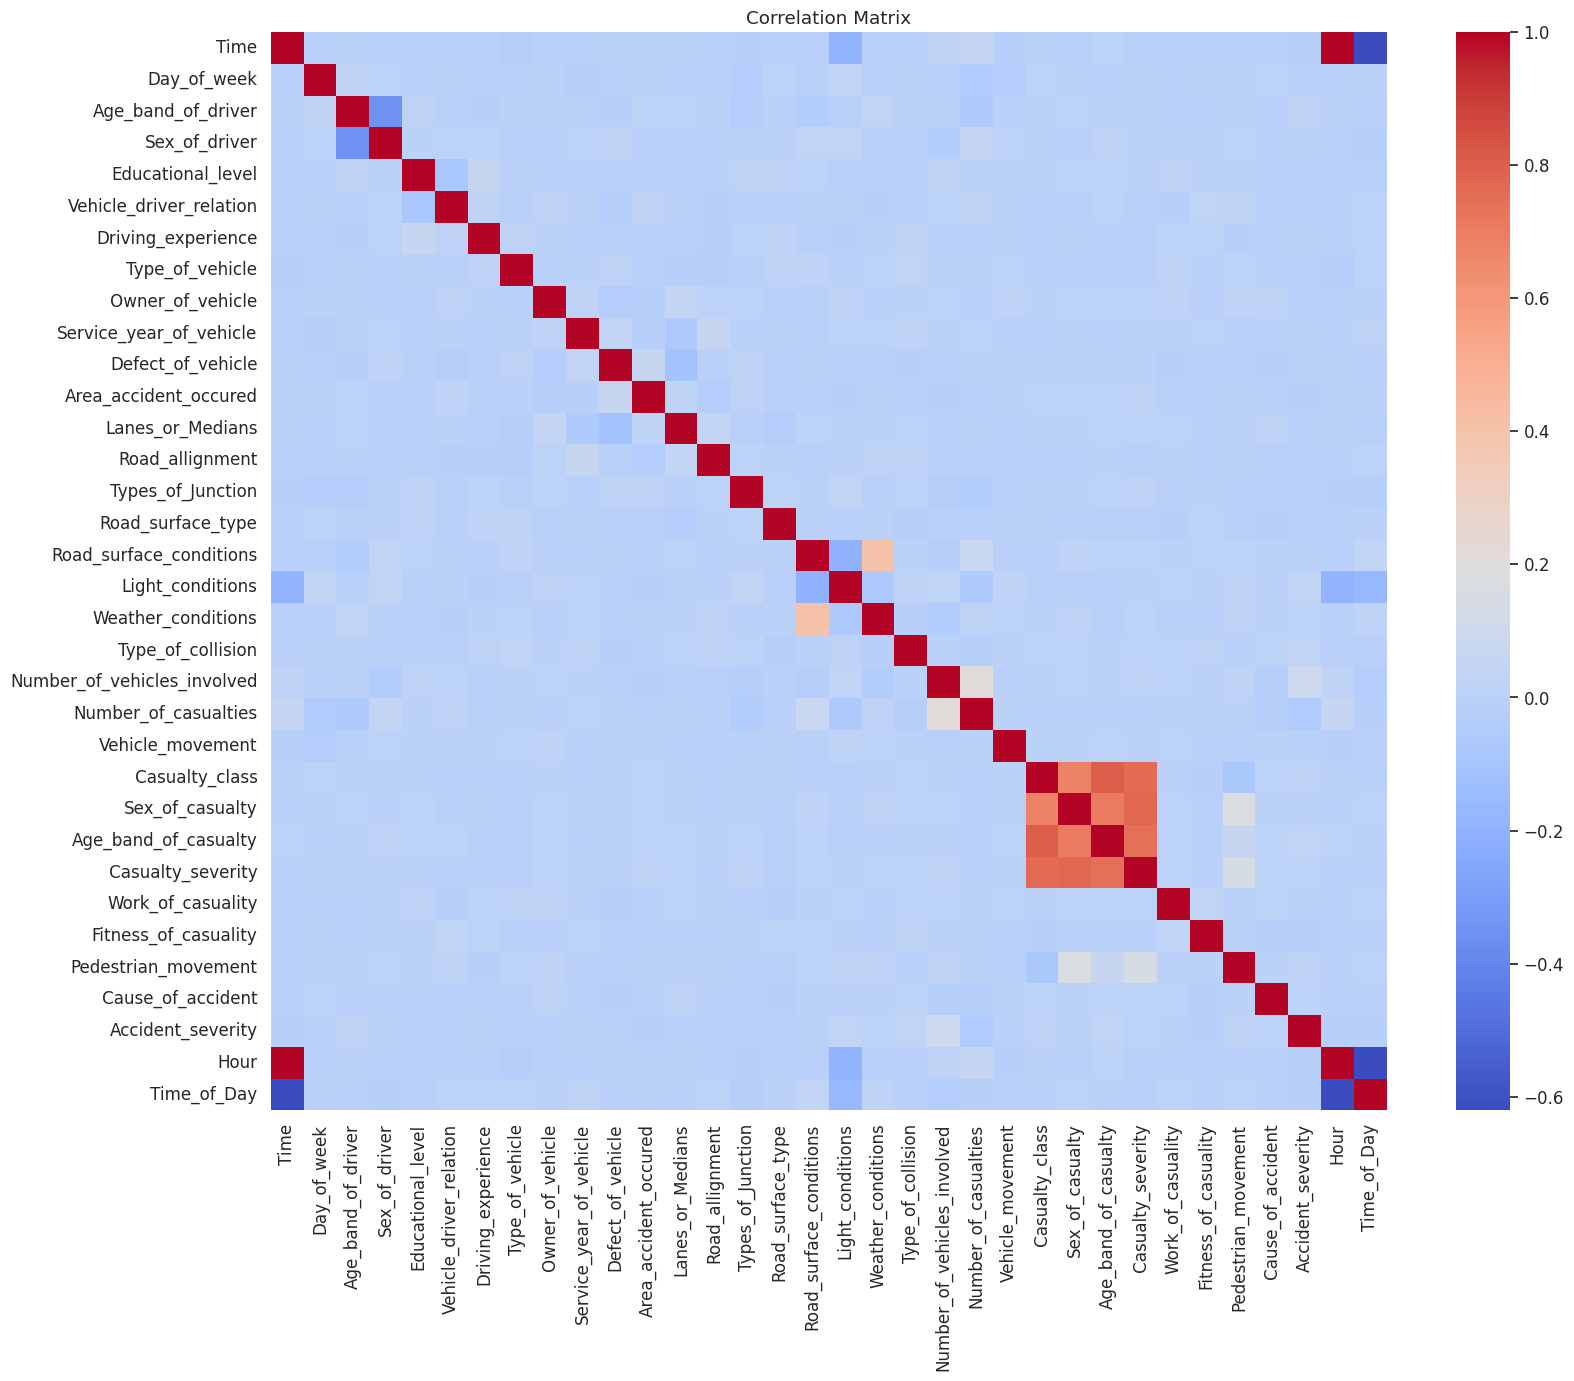

In [33]:
# PLOTING OF CORRELATION MATRIX

plt.figure(figsize=(18,14))

sns.heatmap(
    encoded.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

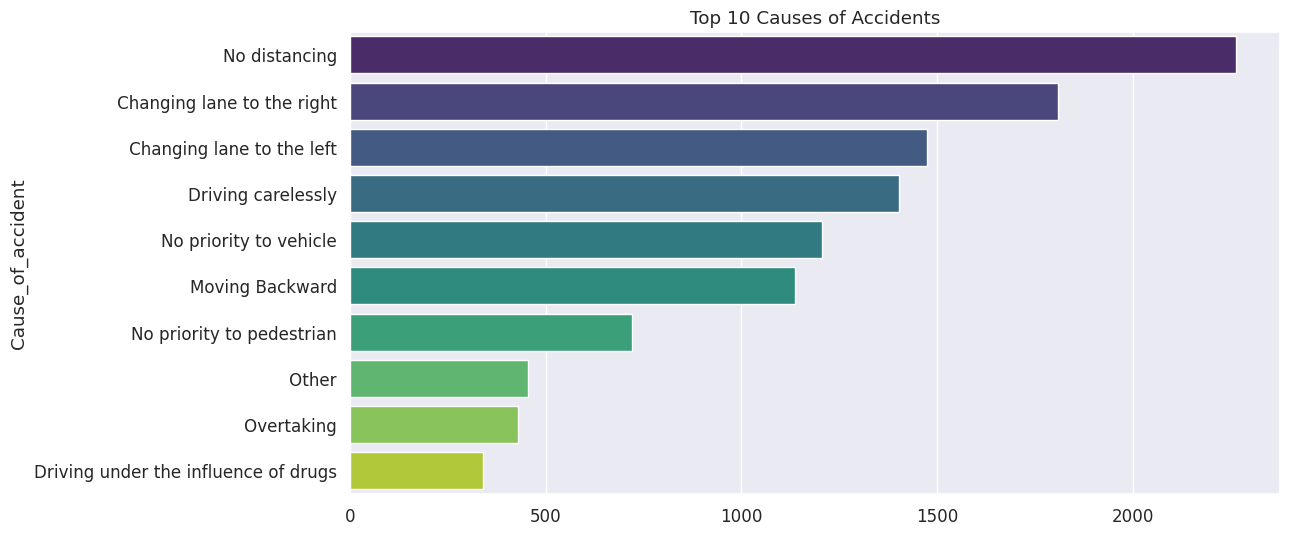

In [34]:
# TOP 10 CAUSES

top = df["Cause_of_accident"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top.values,
    y=top.index,
    palette="viridis"
)

plt.title("Top 10 Causes of Accidents")

plt.show()

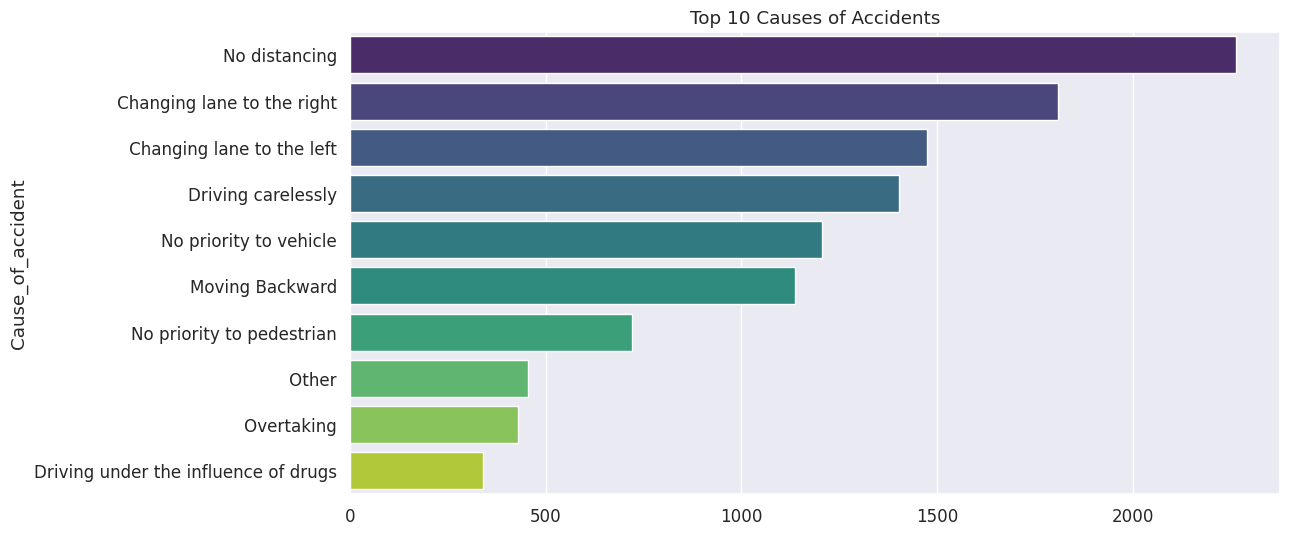

In [35]:
# TOP 10 HOTSPOTS (AREAS)

top = df["Cause_of_accident"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top.values,
    y=top.index,
    palette="viridis"
)

plt.title("Top 10 Causes of Accidents")

plt.show()

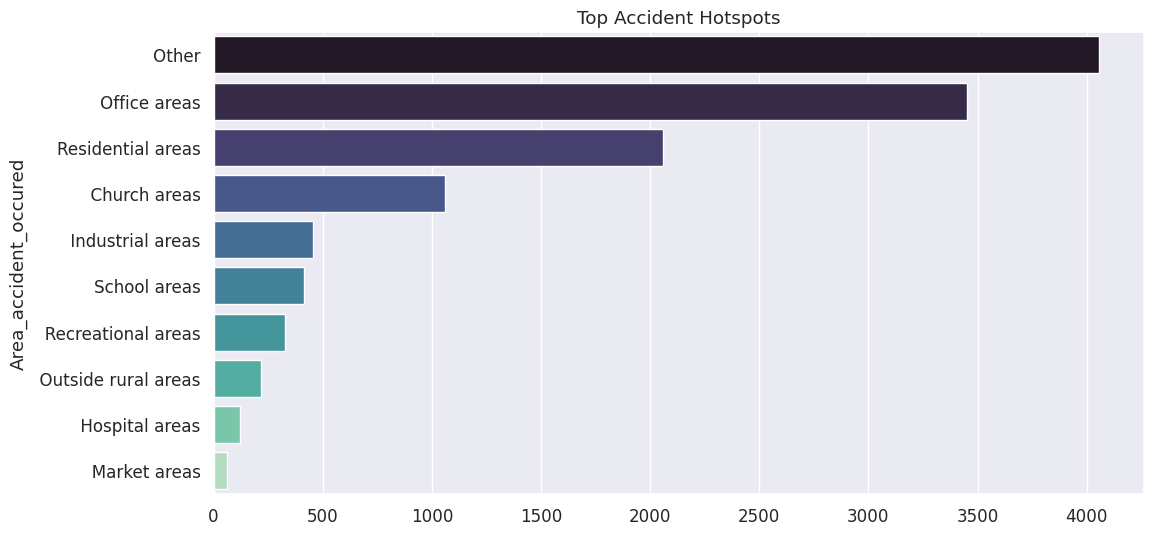

In [36]:
top_places = df["Area_accident_occured"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_places.values,
    y=top_places.index,
    palette="mako"
)

plt.title("Top Accident Hotspots")

plt.show()

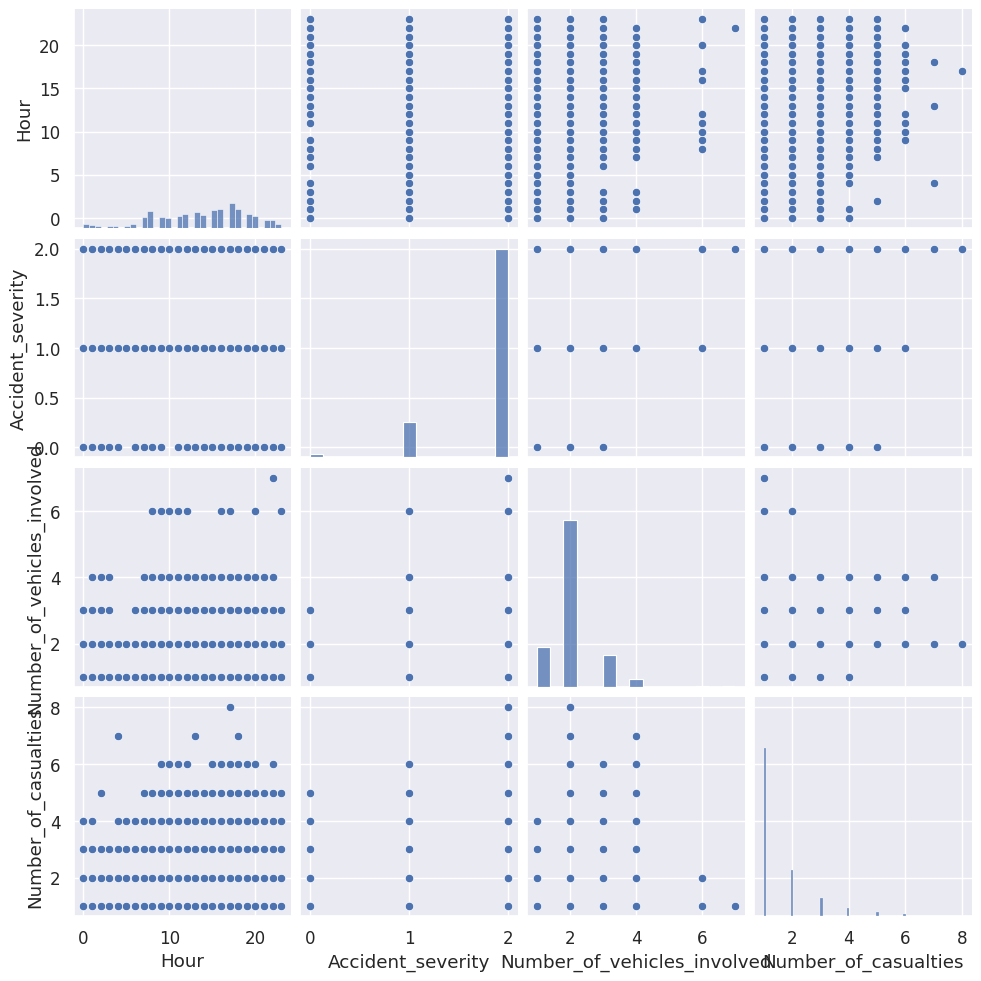

In [37]:
# PAIRPLOT (PROFESSIONAL EDA)

sns.pairplot(
    encoded[
        [
            "Hour",
            "Accident_severity",
            "Number_of_vehicles_involved",
            "Number_of_casualties"
        ]
    ]
)

plt.show()

In [38]:
# FINAL INSIGHTS

print("="*60)
print("PROJECT INSIGHTS")
print("="*60)

print("1. Most accidents occurred during:", df["Time_of_Day"].mode()[0])

print("2. Worst weather condition:",
      df["Weather_conditions"].mode()[0])

print("3. Most common road surface:",
      df["Road_surface_conditions"].mode()[0])

print("4. Highest accident cause:",
      df["Cause_of_accident"].mode()[0])

print("5. Most affected driver age:",
      df["Age_band_of_driver"].mode()[0])

print("6. Most accident-prone day:",
      df["Day_of_week"].mode()[0])

PROJECT INSIGHTS
1. Most accidents occurred during: Afternoon
2. Worst weather condition: Normal
3. Most common road surface: Dry
4. Highest accident cause: No distancing
5. Most affected driver age: 18-30
6. Most accident-prone day: Friday


In [39]:
print("==================================")
print("TASKS 4 IS COMPLETED....")
print("==================================")

TASKS 4 IS COMPLETED....
